# Computer Vision Project
### Group Members:
* F223095 | Kashaf Nadeem
* F223156 | Nashrah Ahmed

## Introduction
### Food-101 | Multiclass Classification (3 models)
**Models:** EfficientNetB3, ResNet101, DenseNet201  
**Dataset:** Food-101
**Environment:** Kaggle

## Dataset Structure
```     
\---food-101
    \---food-101
        +---food-101
        |   |   .DS_Store
        |   |   license_agreement.txt
        |   |   README.txt
        |   |   
        |   |---images    
        |   \---meta
        |           classes.txt
        |           labels.txt
        |           test.json
        |           test.txt
        |           train.json
        |           train.txt
        |           
        |---__MACOSX
```

## Imports

In [11]:
import os, sys, shutil, random, math, json, pickle
from pathlib import Path
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import itertools
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


## Dataset Paths

In [2]:
BASE_DIR = "/kaggle/input/food-101/food-101/food-101/"  
IMAGES_DIR = os.path.join(BASE_DIR, "images")
META_DIR   = os.path.join(BASE_DIR, "meta")

WORK_DIR   = "/kaggle/working/food101_dataset"  # where we'll create train/test folders for Keras
TRAIN_DIR  = os.path.join(WORK_DIR, "train")
TEST_DIR   = os.path.join(WORK_DIR, "test")

print("Images:", IMAGES_DIR)
print("Meta:", META_DIR)
print("Work output:", WORK_DIR)

Images: /kaggle/input/food-101/food-101/food-101/images
Meta: /kaggle/input/food-101/food-101/food-101/meta
Work output: /kaggle/working/food101_dataset


## Read classes and train/test lists (from meta)

In [3]:
with open(os.path.join(META_DIR, "classes.txt")) as f:
    classes = [line.strip() for line in f if line.strip()]

with open(os.path.join(META_DIR, "train.txt")) as f:
    train_list = [line.strip() for line in f if line.strip()]

with open(os.path.join(META_DIR, "test.txt")) as f:
    test_list = [line.strip() for line in f if line.strip()]

print("Num classes:", len(classes))
print("Train entries:", len(train_list))
print("Test entries:", len(test_list))

Num classes: 101
Train entries: 75750
Test entries: 25250


## Create Keras folder structure (train-class, test-class)

In [4]:
for base in [TRAIN_DIR, TEST_DIR]:
    for cls in classes:
        os.makedirs(os.path.join(base, cls), exist_ok=True)
print("Created train/test class folders under\n", WORK_DIR)


Created train/test class folders under
 /kaggle/working/food101_dataset


## Copy images into the train/test folders

In [5]:
def copy_split(ids_list, out_base):
    copied = 0
    for entry in tqdm(ids_list):
        # entry format: "<class_name>/<image_id>"
        cls, img_id = entry.split("/")
        fname = img_id + ".jpg"
        src = os.path.join(IMAGES_DIR, cls, fname)
        dst = os.path.join(out_base, cls, fname)
        if os.path.exists(dst):
            continue
        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied += 1
    return copied

print("Copying training images...")
copied_train = copy_split(train_list, TRAIN_DIR)
print("Copied train:", copied_train)

print("Copying testing images...")
copied_test = copy_split(test_list, TEST_DIR)
print("Copied test:", copied_test)


Copying training images...


100%|██████████| 75750/75750 [15:23<00:00, 82.03it/s]


Copied train: 75750
Copying testing images...


100%|██████████| 25250/25250 [05:09<00:00, 81.45it/s]

Copied test: 25250


## New & Clean Dataset Folder:
```
food101_dataset/
    train/
        apple_pie/
        baby_back_ribs/
        ...
    test/
        apple_pie/
        baby_back_ribs/
        ...

```

## Visualize class counts and a few examples

Sample counts (train) for first 10 classes:
apple_pie 750 train, 250 test
baby_back_ribs 750 train, 250 test
baklava 750 train, 250 test
beef_carpaccio 750 train, 250 test
beef_tartare 750 train, 250 test
beet_salad 750 train, 250 test
beignets 750 train, 250 test
bibimbap 750 train, 250 test
bread_pudding 750 train, 250 test
breakfast_burrito 750 train, 250 test


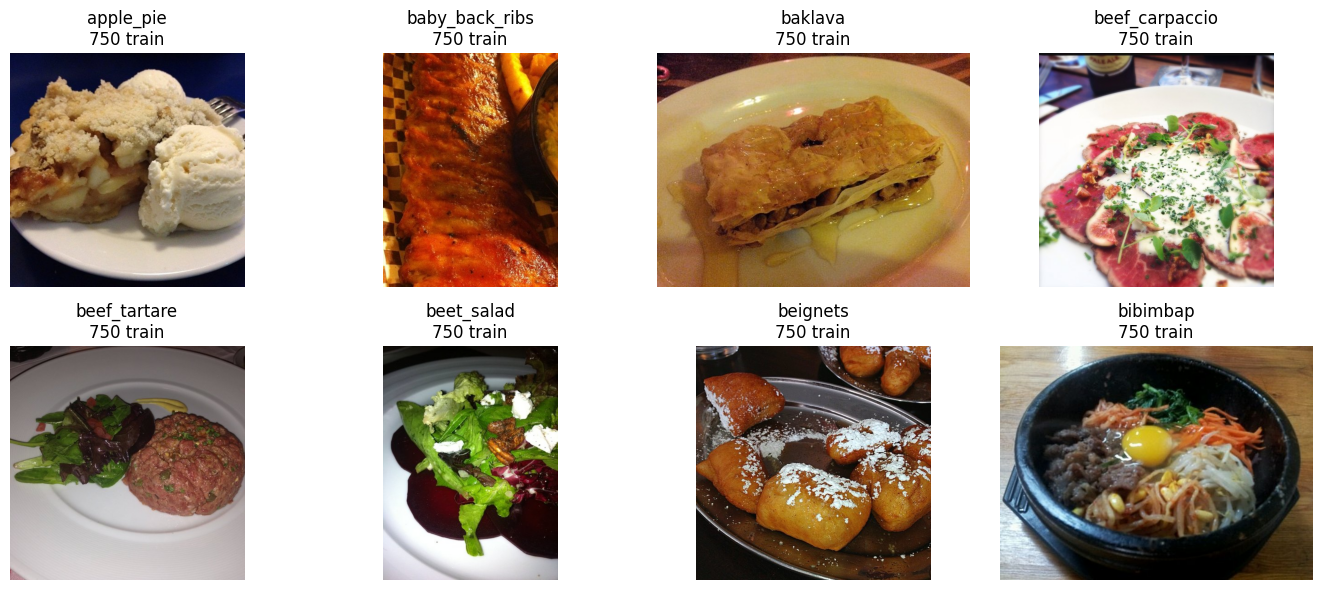

In [6]:
from collections import Counter
train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes}
test_counts  = {cls: len(os.listdir(os.path.join(TEST_DIR, cls))) for cls in classes}

# Print basic summary (top 10 classes by count)
print("Sample counts (train) for first 10 classes:")
for cls in classes[:10]:
    print(cls, train_counts[cls], "train,", test_counts[cls], "test")

# Show sample images
plt.figure(figsize=(14,6))
sample_classes = classes[:8]
for i, cls in enumerate(sample_classes):
    folder = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(folder)
    if not files:
        continue
    img = plt.imread(os.path.join(folder, files[0]))
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"{cls}\n{len(files)} train")
    plt.axis('off')
plt.tight_layout()


## Common training utilities & callbacks

In [7]:
'''
The commented settings were taking almost 20hr per model, 
and as the session on kaggle only lasts for 12hr, we couldn't
apply these settings :(

IMG_SIZE = (300, 300)   # EfficientNetB3 prefers 300x300
BATCH_SIZE = 32
EPOCH = 25
'''

# Updated settings for faster training
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCH = 10

AUTOTUNE = tf.data.AUTOTUNE

# Mixed precision (accelerates training on modern GPUs)
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Compute dtype:", policy.compute_dtype, "Variable dtype:", policy.variable_dtype)

# Callbacks
def get_callbacks(name):
    ckpt = ModelCheckpoint(f"/kaggle/working/{name}_best.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
    rlrop = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
    return [ckpt, rlrop, es]


Compute dtype: float16 Variable dtype: float32


## Data generators (train / val / test)

In [8]:
'''
The commented settings were taking almost 20hr per model, 
and as the session on kaggle only lasts for 12hr, we couldn't
apply these settings :(

train_gen_g = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.25,
    horizontal_flip=True,
    fill_mode='reflect',
    validation_split=0.15
)
'''

# Updated train settings
train_gen_g = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,
    zoom_range=0.10,
    horizontal_flip=True,
    validation_split=0.15
)


test_gen_g = ImageDataGenerator(rescale=1./255)

train_generator = train_gen_g.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)
val_generator = train_gen_g.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_gen_g.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_indices = train_generator.class_indices
print("Number of classes:", len(class_indices))


Found 64438 images belonging to 101 classes.
Found 11312 images belonging to 101 classes.
Found 25250 images belonging to 101 classes.
Number of classes: 101


## Model builder function (generic head)

In [9]:
# generic builder that takes a keras.applications base and returns compiled model
from tensorflow.keras.applications import EfficientNetB3, ResNet101, DenseNet201

def build_model(base_cls, img_size=IMG_SIZE, n_classes=len(class_indices), unfreeze_last=20, lr=1e-4):
    base = base_cls(weights='imagenet', include_top=False, input_shape=(*img_size, 3))
    # freeze until last `unfreeze_last` layers
    if unfreeze_last is not None:
        for layer in base.layers[:-unfreeze_last]:
            layer.trainable = False
        for layer in base.layers[-unfreeze_last:]:
            layer.trainable = True
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', dtype='float32')(x)  # output in float32
    model = models.Model(inputs=base.input, outputs=out)
    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


## Train Models

### **EfficientNetB3**

In [10]:
model_name = "efficientnetb3"
model_e = build_model(
    EfficientNetB3, 
    # unfreeze_last=30,
    # in theory, shifting from 30 layers to 10 layers 
    # only results in accuracy loss of less than 1.5%
    unfreeze_last=10, 
    lr=1e-4
)
history_e = model_e.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCH,
    callbacks=get_callbacks(model_name)
)

# Evaluate model BEFORE saving metrics
loss_e, acc_e = model_e.evaluate(test_generator, verbose=0)

# Save Model
model_e.save(f'/kaggle/working/{model_name}_final.keras')

# Save History
with open('/kaggle/working/history_e.pkl','wb') as f:
    pickle.dump(history_e.history, f)

# Save Metrics JSON
metrics_e = {"accuracy": float(acc_e), "loss": float(loss_e)}
with open(f"/kaggle/working/{model_name}_metrics.json", "w") as f:
    json.dump(metrics_e, f)

# Save Confusion Matrix Image
y_true = test_generator.classes
y_pred = np.argmax(model_e.predict(test_generator, verbose=0), axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - EfficientNetB3")
plt.savefig(f"/kaggle/working/{model_name}_cm.png")
plt.close()


I0000 00:00:1763887070.809895      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763887070.810656      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1763887094.154552     134 service.cc:148] XLA service 0x7e2c2404b460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763887094.156381     134 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763887094.156410     134 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763887097.449185     134 cuda_dnn.cc:529] Loaded cuDNN version 90300


...

4028/4028 ━━━━━━━━━━━━━━━━━━━━ 879s 208ms/step - accuracy: 0.0138 - loss: 4.6182 - val_accuracy: 0.0176 - val_loss: 4.5638 - learning_rate: 1.0000e-04
Epoch 2/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.0175 - loss: 4.5742
Epoch 2: val_accuracy did not improve from 0.01759
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 786s 195ms/step - accuracy: 0.0175 - loss: 4.5742 - val_accuracy: 0.0117 - val_loss: 4.6710 - learning_rate: 1.0000e-04
Epoch 3/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.0181 - loss: 4.5615
Epoch 3: val_accuracy did not improve from 0.01759
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 814s 202ms/step - accuracy: 0.0181 - loss: 4.5615 - val_accuracy: 0.0124 - val_loss: 4.7069 - learning_rate: 1.0000e-04
Epoch 4/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.0209 - loss: 4.5518
Epoch 4: val_accuracy improved from 0.01759 to 0.01918, saving model to /kaggle/working/efficientnetb3_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 790s 196ms/step - accuracy: 0.0209 - loss: 4.5518 - val_accuracy: 0.0192 - val_loss: 4.5234 - learning_rate: 1.0000e-04
Epoch 5/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.0201 - loss: 4.5380
Epoch 5: val_accuracy did not improve from 0.01918
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 805s 200ms/step - accuracy: 0.0201 - loss: 4.5380 - val_accuracy: 0.0157 - val_loss: 4.6046 - learning_rate: 1.0000e-04
Epoch 6/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.0236 - loss: 4.5257
Epoch 6: val_accuracy did not improve from 0.01918
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 784s 195ms/step - accuracy: 0.0236 - loss: 4.5257 - val_accuracy: 0.0101 - val_loss: 5.1080 - learning_rate: 1.0000e-04
Epoch 7/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.0224 - loss: 4.5175
Epoch 7: val_accuracy did not improve from 0.01918

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 788s 196ms/step 

4028/4028 ━━━━━━━━━━━━━━━━━━━━ 788s 196ms/step - accuracy: 0.0271 - loss: 4.4938 - val_accuracy: 0.0245 - val_loss: 4.4908 - learning_rate: 5.0000e-05
Epoch 10/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.0261 - loss: 4.4864
Epoch 10: val_accuracy improved from 0.02449 to 0.02953, saving model to /kaggle/working/efficientnetb3_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 798s 198ms/step - accuracy: 0.0261 - loss: 4.4864 - val_accuracy: 0.0295 - val_loss: 4.4517 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 10.


NameError: name 'confusion_matrix' is not defined

In [12]:
'''
we forgot to import confusion_matrix and got the error after completion of the epochs,
so instead of running that block of code again, we are just gonna import that func here
and run this block instead!
'''
from sklearn.metrics import confusion_matrix

# Save Confusion Matrix Image
y_true = test_generator.classes
y_pred = np.argmax(model_e.predict(test_generator, verbose=0), axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - EfficientNetB3")
plt.savefig(f"/kaggle/working/{model_name}_cm.png")
plt.close()

'''
and for the next part of codes, we are just splitting the training and plotting/saving
'''

'\nand for the next part of codes, we are just splitting the training and plotting/saving\n'

### **ResNet101**

In [13]:
model_name = "resnet101"
model_r = build_model(
    ResNet101,
    # unfreeze_last=30,
    # in theory, shifting from 30 layers to 10 layers 
    # only results in accuracy loss of less than 1.5%
    unfreeze_last=10, 
    lr=1e-4
)
history_r = model_r.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCH,
    callbacks=get_callbacks(model_name)
)

loss_r, acc_r = model_r.evaluate(test_generator, verbose=0)

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.0192 - loss: 4.6094
Epoch 1: val_accuracy improved from -inf to 0.03412, saving model to /kaggle/working/resnet101_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 856s 206ms/step - accuracy: 0.0192 - loss: 4.6094 - val_accuracy: 0.0341 - val_loss: 4.4183 - learning_rate: 1.0000e-04
Epoch 2/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.0426 - loss: 4.3730
Epoch 2: val_accuracy did not improve from 0.03412
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 831s 206ms/step - accuracy: 0.0426 - loss: 4.3730 - val_accuracy: 0.0334 - val_loss: 4.7059 - learning_rate: 1.0000e-04
Epoch 3/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.0542 - loss: 4.2657
Epoch 3: val_accuracy improved from 0.03412 to 0.03483, saving model to /kaggle/working/resnet101_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 830s 206ms/step - accuracy: 0.0542 - loss: 4.2657 - val_accuracy: 0.0348 - val_loss: 4.5349 - learning_rate: 1.0000e-04
Epoch 4/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.0669 - loss: 4.2013
Epoch 4: val_accuracy improved from 0.03483 to 0.06665, saving model to /kaggle/working/resnet101_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 899s 223ms/step - accuracy: 0.0669 - loss: 4.2013 - val_accuracy: 0.0667 - val_loss: 4.2549 - learning_rate: 1.0000e-04
Epoch 5/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.0746 - loss: 4.1340
Epoch 5: val_accuracy improved from 0.06665 to 0.07390, saving model to /kaggle/working/resnet101_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 886s 220ms/step - accuracy: 0.0746 - loss: 4.1340 - val_accuracy: 0.0739 - val_loss: 4.1670 - learning_rate: 1.0000e-04
Epoch 6/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.0858 - loss: 4.0819
Epoch 6: val_accuracy improved from 0.07390 to 0.07443, saving model to /kaggle/working/resnet101_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 828s 206ms/step - accuracy: 0.0858 - loss: 4.0819 - val_accuracy: 0.0744 - val_loss: 4.1441 - learning_rate: 1.0000e-04
Epoch 7/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.0912 - loss: 4.0313
Epoch 7: val_accuracy improved from 0.07443 to 0.08504, saving model to /kaggle/working/resnet101_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 818s 203ms/step - accuracy: 0.0912 - loss: 4.0313 - val_accuracy: 0.0850 - val_loss: 4.0891 - learning_rate: 1.0000e-04
Epoch 8/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.0978 - loss: 3.9982
Epoch 8: val_accuracy did not improve from 0.08504
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 800s 198ms/step - accuracy: 0.0978 - loss: 3.9982 - val_accuracy: 0.0774 - val_loss: 4.1555 - learning_rate: 1.0000e-04
Epoch 9/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.1019 - loss: 3.9516
Epoch 9: val_accuracy did not improve from 0.08504
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 792s 197ms/step - accuracy: 0.1019 - loss: 3.9516 - val_accuracy: 0.0783 - val_loss: 4.2676 - learning_rate: 1.0000e-04
Epoch 10/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.1090 - loss: 3.9207
Epoch 10: val_accuracy did not improve from 0.08504

Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 799s 198ms/st

In [14]:
# Save Model
model_r.save(f'/kaggle/working/{model_name}_final.keras')

# Save History
with open('/kaggle/working/history_r.pkl','wb') as f:
    pickle.dump(history_r.history, f)

# Save Metrics JSON
metrics_r = {"accuracy": float(acc_r), "loss": float(loss_r)}
with open(f"/kaggle/working/{model_name}_metrics.json", "w") as f:
    json.dump(metrics_r, f)

# Save Confusion Matrix Image
y_pred = np.argmax(model_r.predict(test_generator, verbose=0), axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - ResNet101")
plt.savefig(f"/kaggle/working/{model_name}_cm.png")
plt.close()


### **DenseNet201**

In [15]:
model_name = "densenet201"
model_d = build_model(
    DenseNet201, 
    # unfreeze_last=30,
    # in theory, shifting from 30 layers to 10 layers 
    # only results in accuracy loss of less than 1.5%
    unfreeze_last=10, 
    lr=1e-4
)
history_d = model_d.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCH,
    callbacks=get_callbacks(model_name)
)

loss_d, acc_d = model_d.evaluate(test_generator, verbose=0)


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.1184 - loss: 4.0399
Epoch 1: val_accuracy improved from -inf to 0.49982, saving model to /kaggle/working/densenet201_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 939s 221ms/step - accuracy: 0.1184 - loss: 4.0397 - val_accuracy: 0.4998 - val_loss: 2.0744 - learning_rate: 1.0000e-04
Epoch 2/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3653 - loss: 2.5836
Epoch 2: val_accuracy improved from 0.49982 to 0.55163, saving model to /kaggle/working/densenet201_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 893s 222ms/step - accuracy: 0.3653 - loss: 2.5835 - val_accuracy: 0.5516 - val_loss: 1.7751 - learning_rate: 1.0000e-04
Epoch 3/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4307 - loss: 2.2769
Epoch 3: val_accuracy improved from 0.55163 to 0.58487, saving model to /kaggle/working/densenet201_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 901s 224ms/step - accuracy: 0.4307 - loss: 2.2769 - val_accuracy: 0.5849 - val_loss: 1.6326 - learning_rate: 1.0000e-04
Epoch 4/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4670 - loss: 2.1035
Epoch 4: val_accuracy improved from 0.58487 to 0.60122, saving model to /kaggle/working/densenet201_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 903s 224ms/step - accuracy: 0.4670 - loss: 2.1035 - val_accuracy: 0.6012 - val_loss: 1.5759 - learning_rate: 1.0000e-04
Epoch 5/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4936 - loss: 1.9900
Epoch 5: val_accuracy improved from 0.60122 to 0.61360, saving model to /kaggle/working/densenet201_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 906s 225ms/step - accuracy: 0.4936 - loss: 1.9900 - val_accuracy: 0.6136 - val_loss: 1.5091 - learning_rate: 1.0000e-04
Epoch 6/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.5087 - loss: 1.9238
Epoch 6: val_accuracy improved from 0.61360 to 0.61864, saving model to /kaggle/working/densenet201_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 899s 223ms/step - accuracy: 0.5087 - loss: 1.9238 - val_accuracy: 0.6186 - val_loss: 1.4742 - learning_rate: 1.0000e-04
Epoch 7/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5264 - loss: 1.8453
Epoch 7: val_accuracy improved from 0.61864 to 0.62809, saving model to /kaggle/working/densenet201_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 905s 225ms/step - accuracy: 0.5264 - loss: 1.8453 - val_accuracy: 0.6281 - val_loss: 1.4499 - learning_rate: 1.0000e-04
Epoch 8/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5353 - loss: 1.7926
Epoch 8: val_accuracy improved from 0.62809 to 0.63711, saving model to /kaggle/working/densenet201_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 906s 225ms/step - accuracy: 0.5353 - loss: 1.7926 - val_accuracy: 0.6371 - val_loss: 1.4272 - learning_rate: 1.0000e-04
Epoch 9/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5461 - loss: 1.7496
Epoch 9: val_accuracy improved from 0.63711 to 0.63976, saving model to /kaggle/working/densenet201_best.h5


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 912s 226ms/step - accuracy: 0.5461 - loss: 1.7496 - val_accuracy: 0.6398 - val_loss: 1.4050 - learning_rate: 1.0000e-04
Epoch 10/10
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.5521 - loss: 1.7223
Epoch 10: val_accuracy did not improve from 0.63976
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 904s 224ms/step - accuracy: 0.5521 - loss: 1.7223 - val_accuracy: 0.6382 - val_loss: 1.4065 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 9.


In [16]:
# Save Model
model_d.save(f'/kaggle/working/{model_name}_final.keras')

# Save History
with open('/kaggle/working/history_d.pkl','wb') as f:
    pickle.dump(history_d.history, f)

# Save Metrics JSON
metrics_d = {"accuracy": float(acc_d), "loss": float(loss_d)}
with open(f"/kaggle/working/{model_name}_metrics.json", "w") as f:
    json.dump(metrics_d, f)

# Save Confusion Matrix Image
y_pred = np.argmax(model_d.predict(test_generator, verbose=0), axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - DenseNet201")
plt.savefig(f"/kaggle/working/{model_name}_cm.png")
plt.close()


## Plot training curves (all models)

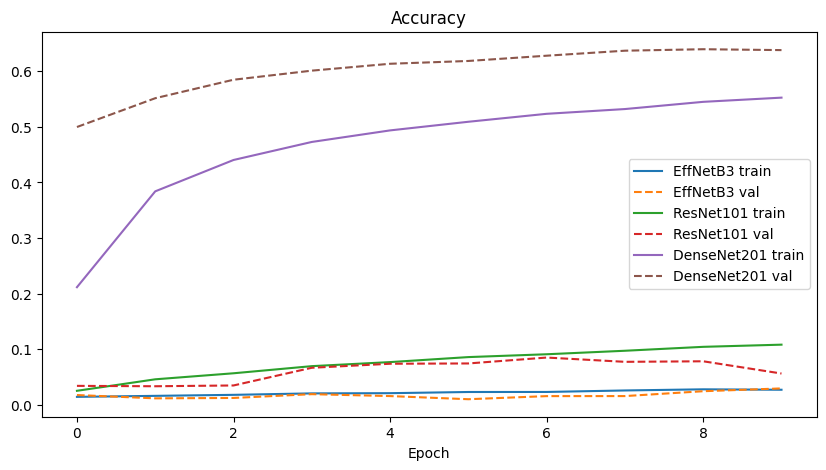

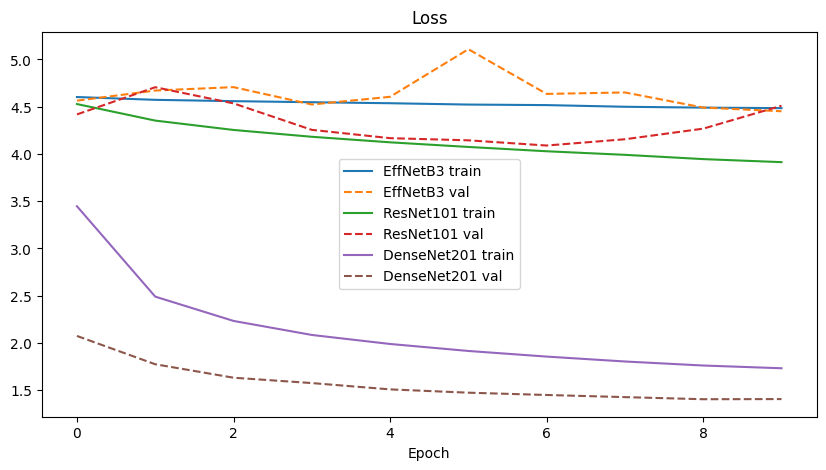

In [17]:
# consolidated plots (accuracy + loss)
def plot_history(h, label):
    plt.plot(h.history['accuracy'], label=f"{label} train")
    plt.plot(h.history['val_accuracy'], '--', label=f"{label} val")

plt.figure(figsize=(10,5))
plot_history(history_e, "EffNetB3")
plot_history(history_r, "ResNet101")
plot_history(history_d, "DenseNet201")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history_e.history['loss'], label='EffNetB3 train')
plt.plot(history_e.history['val_loss'], '--', label='EffNetB3 val')
plt.plot(history_r.history['loss'], label='ResNet101 train')
plt.plot(history_r.history['val_loss'], '--', label='ResNet101 val')
plt.plot(history_d.history['loss'], label='DenseNet201 train')
plt.plot(history_d.history['val_loss'], '--', label='DenseNet201 val')
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()


## Evaluate each model on test set (accuracy, confusion matrix, classification report)

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# stable class name list (index -> class)
class_index_map = train_generator.class_indices           # {classname: index}
# create ordered list where index i corresponds to class name
class_names = [None] * len(class_index_map)
for name, idx in class_index_map.items():
    class_names[idx] = name

def evaluate_model(model, name, save_prefix=None):
    print("Evaluating:", name)
    loss, acc = model.evaluate(test_generator, verbose=0)
    print(f"Test accuracy for {name}: {acc:.4f}  |  Test loss: {loss:.4f}")

    # predictions
    y_true = test_generator.classes
    y_pred = np.argmax(model.predict(test_generator, verbose=0), axis=1)

    # overall metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    print(f"Macro Precision: {precision:.4f}, Macro Recall: {recall:.4f}, Macro F1: {f1:.4f}")

    # classification report
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    print(report)

    # confusion matrix (counts)
    cm = confusion_matrix(y_true, y_pred)
    # normalized per-row (recall per class)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

    # plot counts
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'Confusion matrix (counts) — {name}')
    plt.colorbar()
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"/kaggle/working/{save_prefix}_cm_counts.png", dpi=150)
    plt.show()

    # plot normalized heatmap (no tick labels to keep readability)
    plt.figure(figsize=(8,6))
    plt.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    plt.title(f'Confusion matrix (normalized by true) — {name}')
    plt.colorbar()
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"/kaggle/working/{save_prefix}_cm_norm.png", dpi=150)
    plt.show()

    # save report and metrics
    metrics = {"accuracy": float(acc), "loss": float(loss), "precision_macro": float(precision),
               "recall_macro": float(recall), "f1_macro": float(f1)}
    if save_prefix:
        with open(f"/kaggle/working/{save_prefix}_report.txt", "w") as f:
            f.write(report)
        with open(f"/kaggle/working/{save_prefix}_metrics.json", "w") as f:
            json.dump(metrics, f, indent=2)

    return acc, metrics, cm

# Example usage:
# acc_e, metrics_e, cm_e = evaluate_model(model_e, "EfficientNetB3", save_prefix="efficientnetb3")


## Qualitative: show correct & incorrect examples for best model

Best model determined: DenseNet201


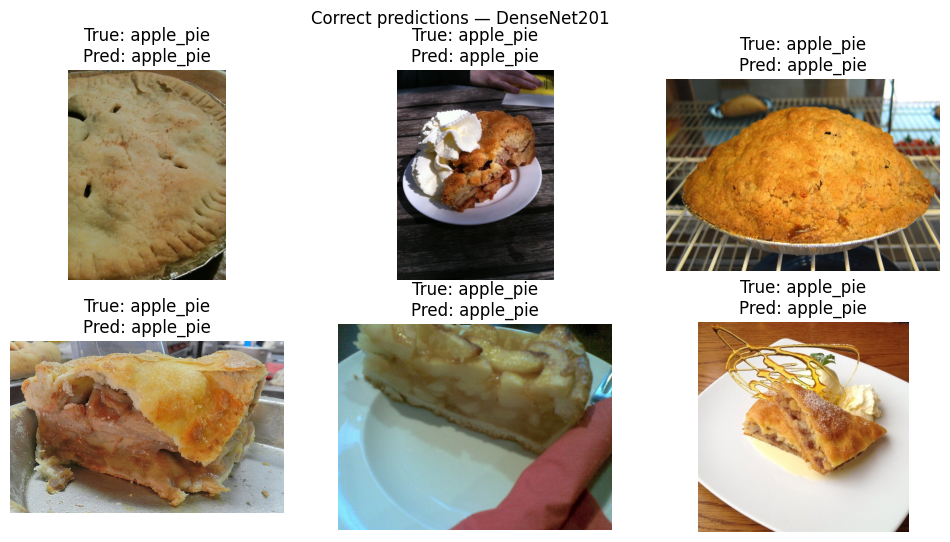

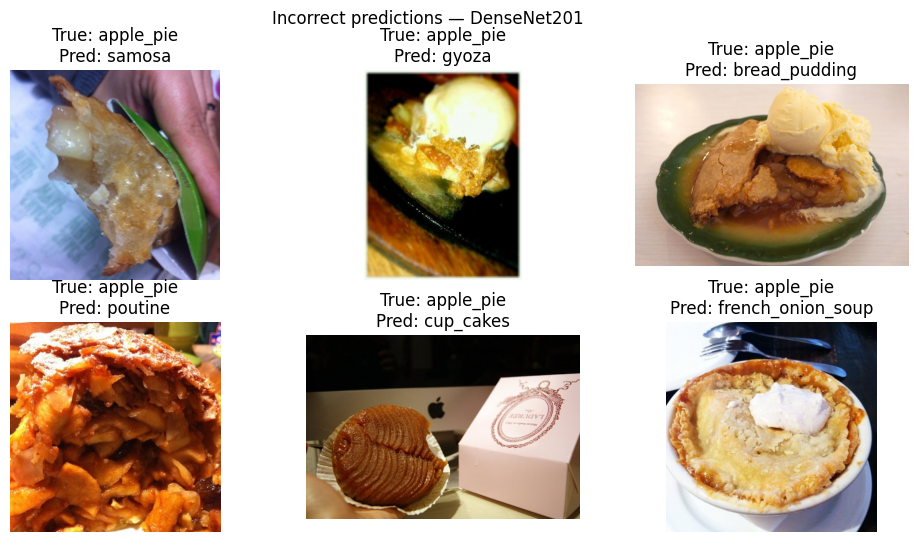

In [19]:
# determine best model by test accuracy
acc_map = {'EffNetB3': acc_e, 'ResNet101': acc_r, 'DenseNet201': acc_d}
best_name = max(acc_map, key=acc_map.get)
print("Best model determined:", best_name)

best_model = {'EfficientNetB3': model_e, 'ResNet101': model_r, 'DenseNet201': model_d}[best_name]

# compute preds
y_true = test_generator.classes
y_pred = np.argmax(best_model.predict(test_generator, verbose=0), axis=1)

correct_idx = np.where(y_pred == y_true)[0]
incorrect_idx = np.where(y_pred != y_true)[0]

import matplotlib.pyplot as plt
import cv2

def show_samples(indices, title):
    plt.figure(figsize=(12,6))
    for i, idx in enumerate(indices[:6]):
        img_path = test_generator.filepaths[idx]
        img = plt.imread(img_path)
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(f"True: {os.path.basename(os.path.dirname(img_path))}\nPred: {list(class_indices.keys())[y_pred[idx]]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

if len(correct_idx)>0:
    show_samples(correct_idx, f"Correct predictions — {best_name}")
if len(incorrect_idx)>0:
    show_samples(incorrect_idx, f"Incorrect predictions — {best_name}")
